In [23]:
from google.colab import files

uploaded = files.upload()

Saving clean_population_data.csv to clean_population_data.csv


In [24]:
import os
print(os.listdir())

['.config', 'clean_population_data.csv', 'sample_data']


In [25]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Load the cleaned CSV
df = pd.read_csv("clean_population_data.csv")

# Connect to SQLite
conn = sqlite3.connect("population_data.db")

# Push data to SQLite
df.to_sql("population_data", conn, index=False, if_exists="replace")

217

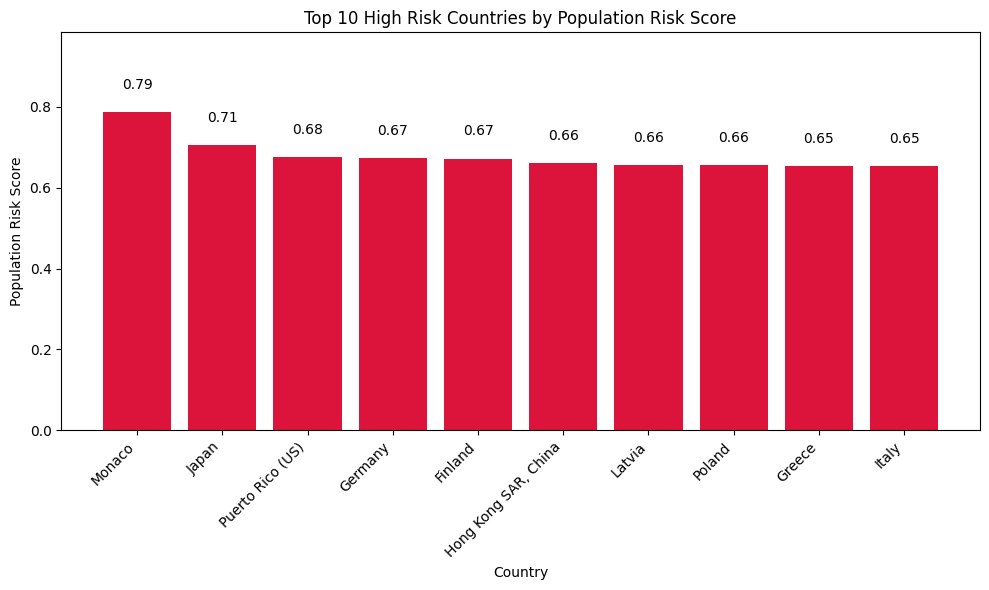

In [27]:
# Top 10 countries with the highest risk
High_Risk_Countries = """
SELECT country, population_risk_score
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;
"""
top_risk = pd.read_sql_query(High_Risk_Countries, conn)

# Make the bar chart
plt.figure(figsize=(10,6))
plt.bar(top_risk['country'], top_risk['population_risk_score'], color='crimson')

# Add labels and title
plt.xlabel("Country")
plt.ylabel("Population Risk Score")
plt.title("Top 10 High Risk Countries by Population Risk Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, top_risk['population_risk_score'].max() * 1.25)

# Optional: add value labels on top of bars
for i, score in enumerate(top_risk['population_risk_score']):
    plt.text(i, score + 0.05, round(score, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Population Risk Score Insight:

The countries with the highest population risk scores tend to have a combination of:
- Low fertility rates
- High dependency ratios
- Negative net migration

This indicates they are at risk of population decline over the coming years.

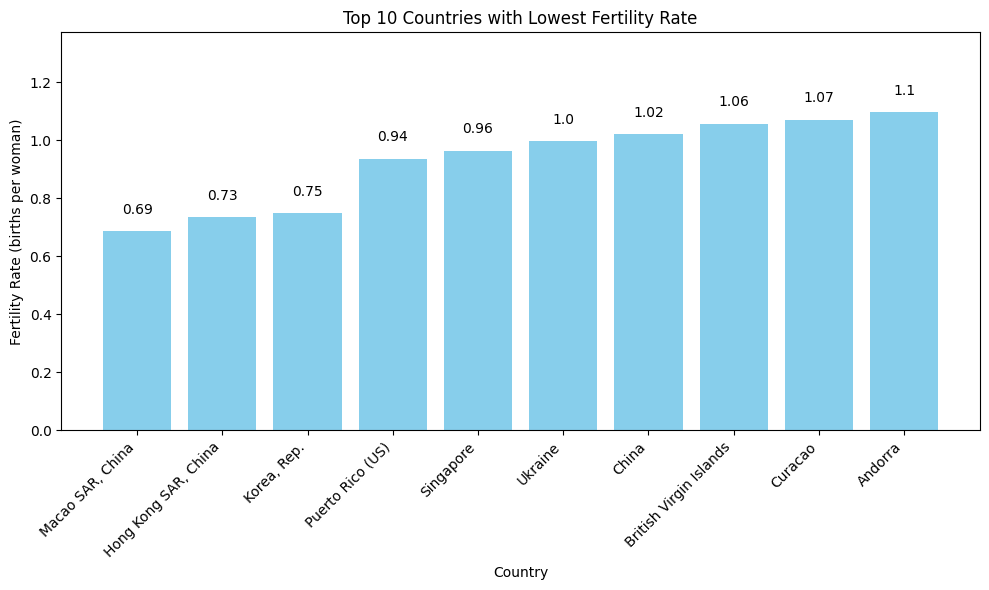

In [28]:
# Top 10 countries with the lowest fertility rates
Low_Fertility_Rate = """SELECT country, fertility_rate
FROM population_data
ORDER BY fertility_rate ASC
LIMIT 10;
"""
Low_fertility = pd.read_sql_query(Low_Fertility_Rate, conn)

# Bar chart for the 10 countries with lowest fertility rates
plt.figure(figsize=(10,6))
plt.bar(Low_fertility['country'], Low_fertility['fertility_rate'], color='skyblue')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Fertility Rate (births per woman)")
plt.title("Top 10 Countries with Lowest Fertility Rate")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, Low_fertility['fertility_rate'].min() * 2)

# Add values on top of each bar
for i, rate in enumerate(Low_fertility['fertility_rate']):
    plt.text(i, rate + 0.05, round(rate, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [56]:
# Counting the number of countries above or below the replacement level
Count_fertility_rate = """SELECT
    CASE
        WHEN fertility_rate < 2.1 THEN 'Below Replacement'
        ELSE 'Above Replacement'
    END AS fertility_status,
    COUNT(*) AS num_countries
FROM population_data
GROUP BY fertility_status
ORDER BY fertility_status;"""

Count_fertility_rate = pd.read_sql_query(Count_fertility_rate, conn)

print(Count_fertility_rate)



    fertility_status  num_countries
0  Above Replacement             96
1  Below Replacement            121


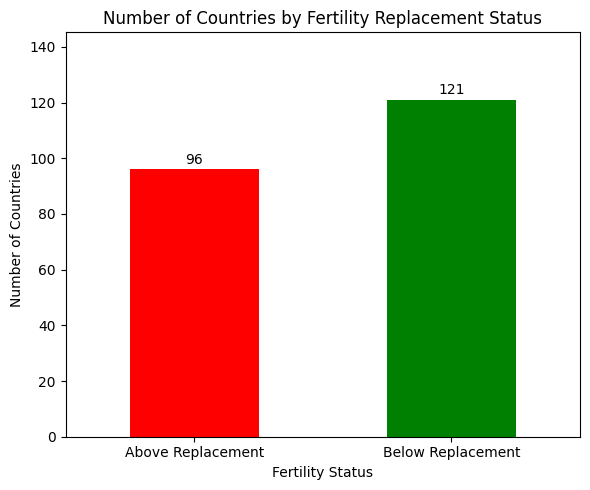

In [69]:
# Bar Chart for number of countries above or below the replacement rate
ax = Count_fertility_rate.set_index('fertility_status')['num_countries'].plot(
    kind='bar',
    color=['red', 'green'],   # Below Replacement = red, Above = green
    figsize=(6,5)
)

# Labels and title
ax.set_xlabel("Fertility Status")
ax.set_ylabel("Number of Countries")
ax.set_title("Number of Countries by Fertility Replacement Status")
plt.ylim(0, Count_fertility_rate['num_countries'].max() * 1.2)
# Quick bar chart using pandas plot

# Make x-axis labels horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

# Add numbers on top of bars
for i, count in enumerate(Count_fertility_rate['num_countries']):
    ax.text(i, count + 1, count, ha='center', va='bottom')

plt.tight_layout()
plt.show()

Fertility Rates Insight

Out of the countries in the dataset, 121 have fertility rates below the replacement level of 2.1 births per woman.

This indicates that a large portion of countries may face population decline in the long term if not offset by migration.

Combined with high dependency ratios in some countries, this could lead to aging populations and economic pressure.

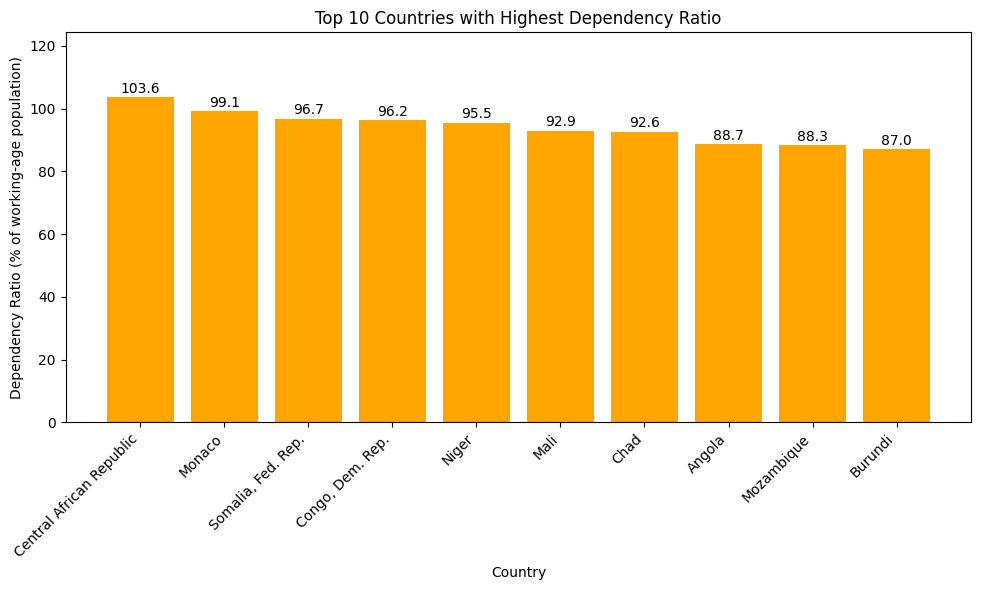

In [29]:
# Top 10 Highest Dependency Ratios
High_Dependency_Ratio = """SELECT country, dependency_ratio
FROM population_data
ORDER BY dependency_ratio DESC
LIMIT 10
"""

High_dependency = pd.read_sql_query(High_Dependency_Ratio, conn)

# Bar chart for countries with highest dependency ratio
plt.figure(figsize=(10,6))
plt.bar(High_dependency['country'], High_dependency['dependency_ratio'], color='orange')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Dependency Ratio (% of working-age population)")
plt.title("Top 10 Countries with Highest Dependency Ratio")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, High_dependency['dependency_ratio'].max() * 1.2)

# Add values on top of bars
for i, ratio in enumerate(High_dependency['dependency_ratio']):
    plt.text(i, ratio + 0.5, round(ratio, 1), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Dependency Ratio Insight:

A dependency ratio measure the number of people of non-working age to the number of people who are of working-age.

The Central African Republic is the only country that has more people of non-working age than people of working age, which is largely due to their high fertitlity rate of 5.9 per woman.

The countries with the highest dependency ratios are all located in Africa, reflecting their high birth-rates and young populations.

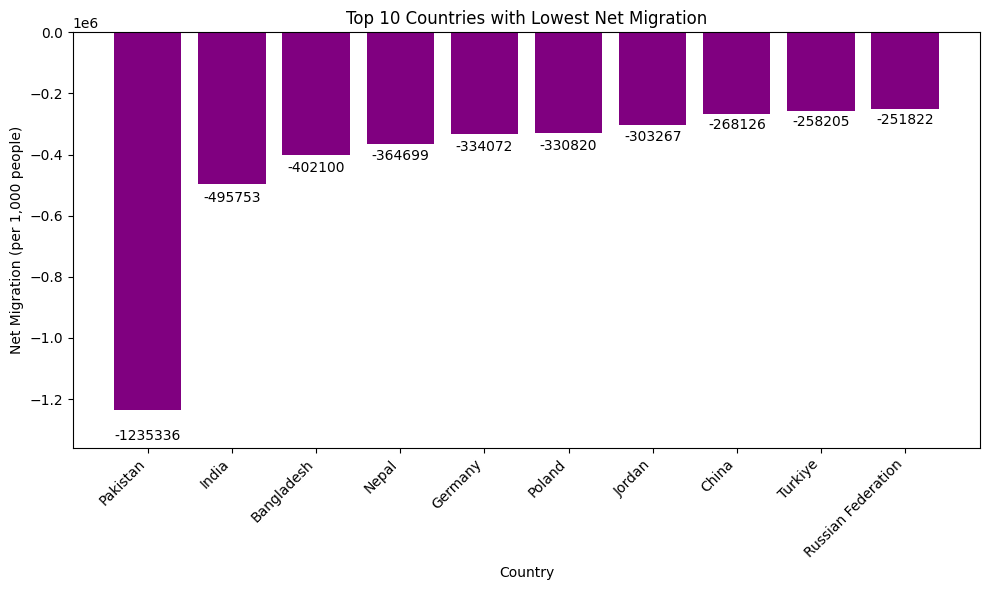

In [30]:
# Top 10 countries lowest net migration
Low_migration = """SELECT country, net_migration
FROM population_data
WHERE net_migration < 0
ORDER BY net_migration ASC
LIMIT 10"""

low_migration = pd.read_sql_query(Low_migration, conn)

# Bar chart for countries with lowest net migration
plt.figure(figsize=(10,6))
plt.bar(low_migration['country'], low_migration['net_migration'], color='purple')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Net Migration (per 1,000 people)")
plt.title("Top 10 Countries with Lowest Net Migration")
plt.xticks(rotation=45, ha='right')
plt.ylim(low_migration['net_migration'].min() * 1.1, 0.5)

# Add labels on top
for i, val in enumerate(low_migration['net_migration']):
    # offset = 5% of the bar height (scales automatically)
    offset = abs(val) * 0.05
    plt.text(i, val - offset, round(val, 1), ha='center', va='top')

plt.tight_layout()
plt.show()

In [38]:
# Count the number of countries that have more people moving out than moving in
Count_Low_migration = """SELECT COUNT(*) AS count_low_migration
FROM population_data
WHERE net_migration < 0
ORDER BY net_migration ASC"""

Count_low_migration = pd.read_sql_query(Count_Low_migration, conn)
print(Count_low_migration)

   count_low_migration
0                  130


Net Migration Insight

Net migration measures the difference between people entering and leaving the coutry. 130 countries have a negative net migration, meaning that more people are leaving than entering.

These countries may face population decline, leading to a labor shortage and economic harship, if it is not set off by other factors.

In [31]:
# Understand the average risk

average_population_risk = """
SELECT AVG(population_risk_score) AS average_risk
FROM population_data

"""
average_population_risk = pd.read_sql_query(average_population_risk, conn)

print(average_population_risk)

   average_risk
0      0.569016


In [52]:
# Understand the upper and low quartile to adequately categorize countries into "High" and "Low" risk

high_threshold = df['population_risk_score'].quantile(0.75)  # top 25%
medium_threshold = df['population_risk_score'].quantile(0.25)  # next 50%

print("High Risk Threshold:", high_threshold)
print("Medium Risk Threshold:", medium_threshold)

High Risk Threshold: 0.6049075065
Medium Risk Threshold: 0.538259621


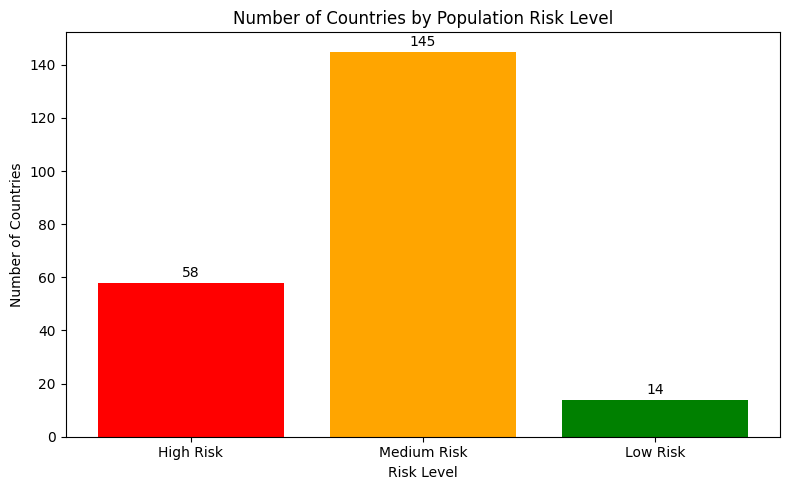

In [55]:


# Categorizing countries by high, medium, and low risk and counting the number that fall into each category
risk_counts = pd.read_sql_query("""
SELECT
    CASE
        WHEN population_risk_score >= 0.6 THEN 'High Risk'
        WHEN population_risk_score >= 0.5 THEN 'Medium Risk'
        ELSE 'Low Risk'
    END AS risk_level,
    COUNT(*) AS num_countries
FROM population_data
GROUP BY risk_level
ORDER BY
    CASE
        WHEN risk_level = 'High Risk' THEN 1
        WHEN risk_level = 'Medium Risk' THEN 2
        ELSE 3
    END;
""", conn)

# Plot
plt.figure(figsize=(8,5))
plt.bar(risk_counts['risk_level'], risk_counts['num_countries'], color=['red','orange','green'])
plt.xlabel("Risk Level")
plt.ylabel("Number of Countries")
plt.title("Number of Countries by Population Risk Level")
plt.xticks(rotation=0)

# Add numbers on top of bars
for i, count in enumerate(risk_counts['num_countries']):
    plt.text(i, count + 1, count, ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [34]:
largest_risk = """SELECT country,
       CASE
           WHEN dependency_ratio >= 60 THEN 'Dependency is main risk'
           WHEN fertility_rate < 2.1 THEN 'Low fertility is main risk'
           WHEN net_migration < 0 THEN 'Migration is main risk'
           ELSE 'No single factor dominates'
       END AS main_risk_factor
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;"""

largest_risk = pd.read_sql_query(largest_risk, conn)

print(largest_risk)

                country            main_risk_factor
0                Monaco     Dependency is main risk
1                 Japan     Dependency is main risk
2      Puerto Rico (US)  Low fertility is main risk
3               Germany     Dependency is main risk
4               Finland     Dependency is main risk
5  Hong Kong SAR, China  Low fertility is main risk
6                Latvia  Low fertility is main risk
7                Poland  Low fertility is main risk
8                Greece  Low fertility is main risk
9                 Italy  Low fertility is main risk
